In [21]:
import numpy as np
import pandas as pd
import xarray as xr
import pickle

dataset = 'REMO'  # 'REMO', 'ISIMIP', 'NEX'

home_dir = '<home_path>'
save_path = '<gcloud_path>'

# load location information
# list locs in alphabetical order. [lat min, lat max, lon min, lon max] or (Lat, lon)
loclatlons = pd.read_csv(f'{home_dir}/{save_path}/latlons.txt', header=None)
list_of_tuples = list(loclatlons.itertuples(index=False, name=None))
locs_dict = {name: [lat - 0.5, lat + 0.5, lon - 0.5, lon + 0.5] for name, lat, lon, descriptor in list_of_tuples} 

variable = 'fwi'

if dataset == 'REMO':
    data_path = '<REMO_data_path>'
    models = ['HadGEM2-ES', 'MPI-ESM-LR', 'NorESM1-M']
elif dataset == 'NEX':
    data_path = '<NEX_data_path>'
    models = ['EC-Earth3', 'GFDL-ESM4', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'UKESM1-0-LL']
elif dataset == 'ISIMIP':
    data_path = '<ISIMIP_data_path>'
    models = ['GFDL-ESM4', 'IPSL-CM6A-LR', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'UKESM1-0-LL']

season = 'Annual'
months2include = {
    'January': 1,
    'February': 2,
    'March': 3,
    'April': 4,
    'May': 5,
    'June':6,
    'July': 7,
    'August': 8,
    'September': 9,
    'October': 10,
    'November': 11,
    'December': 12
}

percentile = 95  # Ex: use 95 for 95th percentile
var_thresholds = {'Low-to-Moderate':7 , 'High':15, 'Very High': 31, 'Extreme': 57}

plot_method = 'ensemble'  # 'ensemble' or 'individual' models

yrs_base = np.arange(2001, 2020 + 1)
yrs_fut = np.arange(2031, 2050 + 1)
yrs_fut2 = []

if variable == 'fwi' and dataset == 'REMO':
    var = 'fwiday'
else: 
    var = variable

locs_dict

{'Altamira': [-3.7034, -2.7034, -52.7096, -51.7096],
 'Cascavel': [-25.4426, -24.4426, -53.9941, -52.9941],
 'Cuiabá': [-16.0963, -15.0963, -56.5802, -55.5802],
 'Manaus': [-3.5868, -2.5868, -60.5141, -59.5141],
 'Palmas': [-10.7509, -9.7509, -48.8235, -47.8235]}

In [ ]:
# read in data and save
df_full = pd.DataFrame()

# loop through models, years, and locations
for m in models:
    for yr in np.arange(1971, 2100 + 1):
        if yr in yrs_base or yr in yrs_fut or yr in yrs_fut2:
            print(yr, m)  
            if dataset == 'REMO':
                ds = xr.open_dataset(f'{home_dir}/{data_path}/{variable}_REMO_{m}_bias-adjusted_V6_{yr}.nc') 
            elif dataset == 'NEX':
                ds = xr.open_dataset(f'{home_dir}/{data_path}/nex-{m}_daily_{variable}_{yr}.nc') 
            elif dataset == 'ISIMIP':
                ds = xr.open_dataset(f'{home_dir}/{data_path}/{variable}_{m}_w5e5_global_daily_{yr}.nc')
            else:
                print('Error! Dataset not recognized.')
                
            # loop through locations
            for loc, latlons in locs_dict.items():
                print(loc)
                if len(latlons) == 4:
                    data = ds.sel(lat=slice(latlons[0], latlons[1]), lon=slice(latlons[2], latlons[3]), \
                                  time=ds.time.dt.month.isin(list(months2include.values())))
                elif len(latlons) == 2:
                    data = (ds.sel(lat=latlons[0], lon=latlons[1], method='nearest', \
                                   time=ds.time.dt.month.isin(list(months2include.values()))))     
                else: 
                    print('Error! Lat/lons should be tuple (lat, lon) or list with length of four [lat min, lat max, lon min, lon max]')

                if yr == yrs_base[0]:
                    print(data[var].shape)
                    
                # stack data into pandas dataframe
                df_loc = data.to_dataframe().reset_index()
                df_loc['model'] = m
                df_loc['location'] = loc

                df_full = (df_loc.copy() if df_full.empty else pd.concat([df_full, df_loc]))
            ds.close()
    else:
        pass
        
df_full.sort_values(by=['time', 'lon', 'lat', 'location', 'model'], inplace=True)

# pickle dictionary
if len(list(locs_dict.values())[0]) == 2:
    with open(f'{home_dir}/{save_path}/{dataset}/{'_'.join([l.replace(" " , "_") for l in list(locs_dict.keys())])}_{variable}_df_{season}_{dataset}_singlepixel.pkl', 'wb') as f:
        pickle.dump(df_full, f)
elif  len(list(locs_dict.values())[0]) == 4:
    with open(f'{home_dir}/{save_path}/{dataset}/{'_'.join([l.replace(" " , "_") for l in list(locs_dict.keys())])}_{variable}_df_{season}_{dataset}_latlonbox.pkl', 'wb') as f:
        pickle.dump(df_full, f)
else:
    print('Error! Lat and lons should be a single point (len == 2) or box (len == 4)!')
    
df_full    

In [22]:
# load dictionary pickle
if len(list(locs_dict.values())[0]) == 2:
    with open(f'{home_dir}/{save_path}/{dataset}/{'_'.join([l.replace(" " , "_") for l in list(locs_dict.keys())])}_{variable}_df_{season}_{dataset}_singlepixel.pkl', 'rb') as f:
        df_full = pickle.load(f)
elif  len(list(locs_dict.values())[0]) == 4:
    with open(f'{home_dir}/{save_path}/{dataset}/{'_'.join([l.replace(" " , "_") for l in list(locs_dict.keys())])}_{variable}_df_{season}_{dataset}_latlonbox.pkl', 'rb') as f:
        df_full = pickle.load(f)
else:
    print('Error! Lat and lons should be a single point (len == 2) or box (len == 4)!')

df_full = df_full.reset_index().drop(columns=['index', 'lon', 'lat'])
df_full

,time,fwiday,model,location
0,2001-01-01,0.000000,HadGEM2-ES,Manaus
1,2001-01-01,0.000000,MPI-ESM-LR,Manaus
2,2001-01-01,0.000000,NorESM1-M,Manaus
3,2001-01-01,0.000000,HadGEM2-ES,Manaus
4,2001-01-01,0.000000,MPI-ESM-LR,Manaus
...,...,...,...,...
5478745,2050-12-31,0.171361,MPI-ESM-LR,Palmas
5478746,2050-12-31,0.643238,NorESM1-M,Palmas
5478747,2050-12-31,16.300507,HadGEM2-ES,Palmas
5478748,2050-12-31,0.135421,MPI-ESM-LR,Palmas


In [25]:
# fire danger percentages (% of time spent in each fire danger category)
bins = [0] + [v for v in var_thresholds.values()] + [1000]

danger_df = pd.DataFrame()

for loc in locs_dict.keys():
    df_temp = pd.DataFrame(columns=['Location', 'Fire Danger'])
    df_temp['Fire Danger'] = ['Low', 'Moderate', 'High', 'Very High', 'Extreme']
    df_temp['Location'] = [loc, '', '', '', '']

    n_time = 2
    if len(yrs_fut2) > 0:
        n_time = 3

    for n in np.arange(n_time):
        if n == 0:
            start_yr, end_yr = yrs_base[0], yrs_base[-1]
        elif n == 1:
            start_yr, end_yr = yrs_fut[0], yrs_fut[-1]
        elif n == 2:        
            start_yr, end_yr = yrs_fut2[0], yrs_fut2[-1]
        else:
            print('Error! Number of time periods is inconsistent.')

        col = f'{start_yr}-{end_yr}'
        df = df_full[(df_full['time'] >= f'{start_yr}-01-01') & (df_full['time'] <= f'{end_yr}-12-31')] 
        
        loc_df = df.loc[df['location'] == loc, var].value_counts(bins=bins).sort_index()
        percentages = np.round(loc_df / loc_df.sum() * 100, 2).reset_index()
        df_temp[col] = percentages['count']

    if n_time == 2:
        df_temp['Percent-Point Difference'] = df_temp[f'{yrs_fut[0]}-{yrs_fut[-1]}'] - df_temp[f'{yrs_base[0]}-{yrs_base[-1]}']
    elif n_time == 3:
        df_temp['Percent-Point Difference'] = df_temp[f'{yrs_fut2[0]}-{yrs_fut2[-1]}'] - df_temp[f'{yrs_base[0]}-{yrs_base[-1]}']

    df_temp['Percent Change'] = np.round(df_temp['Percent-Point Difference'] / np.abs(df_temp[f'{yrs_base[0]}-{yrs_base[-1]}']) * 100, 2)

    danger_df = (df_temp.copy() if danger_df.empty else pd.concat([danger_df, df_temp]))
    
    if len(list(locs_dict.values())[0]) == 2:
        danger_df.to_csv(f'{home_dir}/{save_path}/{dataset}/{'_'.join([l.replace(" " , "_") for l in list(locs_dict.keys())])}_{variable}_df_{season}_{dataset}_singlepixel.csv', index=False)
    elif len(list(locs_dict.values())[0]) == 4:
        danger_df.to_csv(f'{home_dir}/{save_path}/{dataset}/{'_'.join([l.replace(" " , "_") for l in list(locs_dict.keys())])}_{variable}_df_{season}_{dataset}_latlonbox.csv', index=False)
        
danger_df

,Location,Fire Danger,2001-2020,2031-2050,Percent-Point Difference,Percent Change
0,Altamira,Low,77.82,67.64,-10.18,-13.08
1,,Moderate,11.87,12.65,0.78,6.57
2,,High,9.53,17.81,8.28,86.88
3,,Very High,0.79,1.91,1.12,141.77
4,,Extreme,0.00,0.00,0.00,NaN
0,Cascavel,Low,69.62,61.99,-7.63,-10.96
1,,Moderate,21.77,22.66,0.89,4.09
2,,High,7.71,12.41,4.70,60.96
3,,Very High,0.89,2.84,1.95,219.10
4,,Extreme,0.00,0.11,0.11,inf


In [23]:
# get percentile values of base time period, drop all variable data below threshold

# base period
perc_df = df_full[(df_full['time'] >= f'{yrs_base[0]}-01-01') & (df_full['time'] <= f'{yrs_base[-1]}-12-31')] 

perc = percentile / 100
percentiles = perc_df.groupby(['location'])[var].quantile(q=perc, interpolation='linear')
percentiles = np.round(percentiles, decimals=1)

locs_dict = dict(sorted(locs_dict.items()))  # alphabetize locations to match percentile df order
print(percentiles)

# drop values below percentile threshold
for m in models:
    for loc in locs_dict.keys():
        df_full.drop(df_full[(df_full[var] < percentiles[loc]) & (df_full['location'] == loc)].index, inplace=True)
        
df_full

location
Altamira    20.9
Cascavel    17.5
Cuiabá      42.6
Manaus       8.0
Palmas      53.8
Name: fwiday, dtype: float64


,time,fwiday,model,location
2400,2001-01-07,20.325130,HadGEM2-ES,Cascavel
2403,2001-01-07,19.304056,HadGEM2-ES,Cascavel
2406,2001-01-07,19.295597,HadGEM2-ES,Cascavel
2409,2001-01-07,18.427757,HadGEM2-ES,Cascavel
2472,2001-01-07,18.262159,HadGEM2-ES,Cascavel
...,...,...,...,...
5478291,2050-12-30,23.557791,HadGEM2-ES,Altamira
5478294,2050-12-30,23.508553,HadGEM2-ES,Altamira
5478297,2050-12-30,24.080015,HadGEM2-ES,Altamira
5478440,2050-12-31,9.222864,NorESM1-M,Manaus


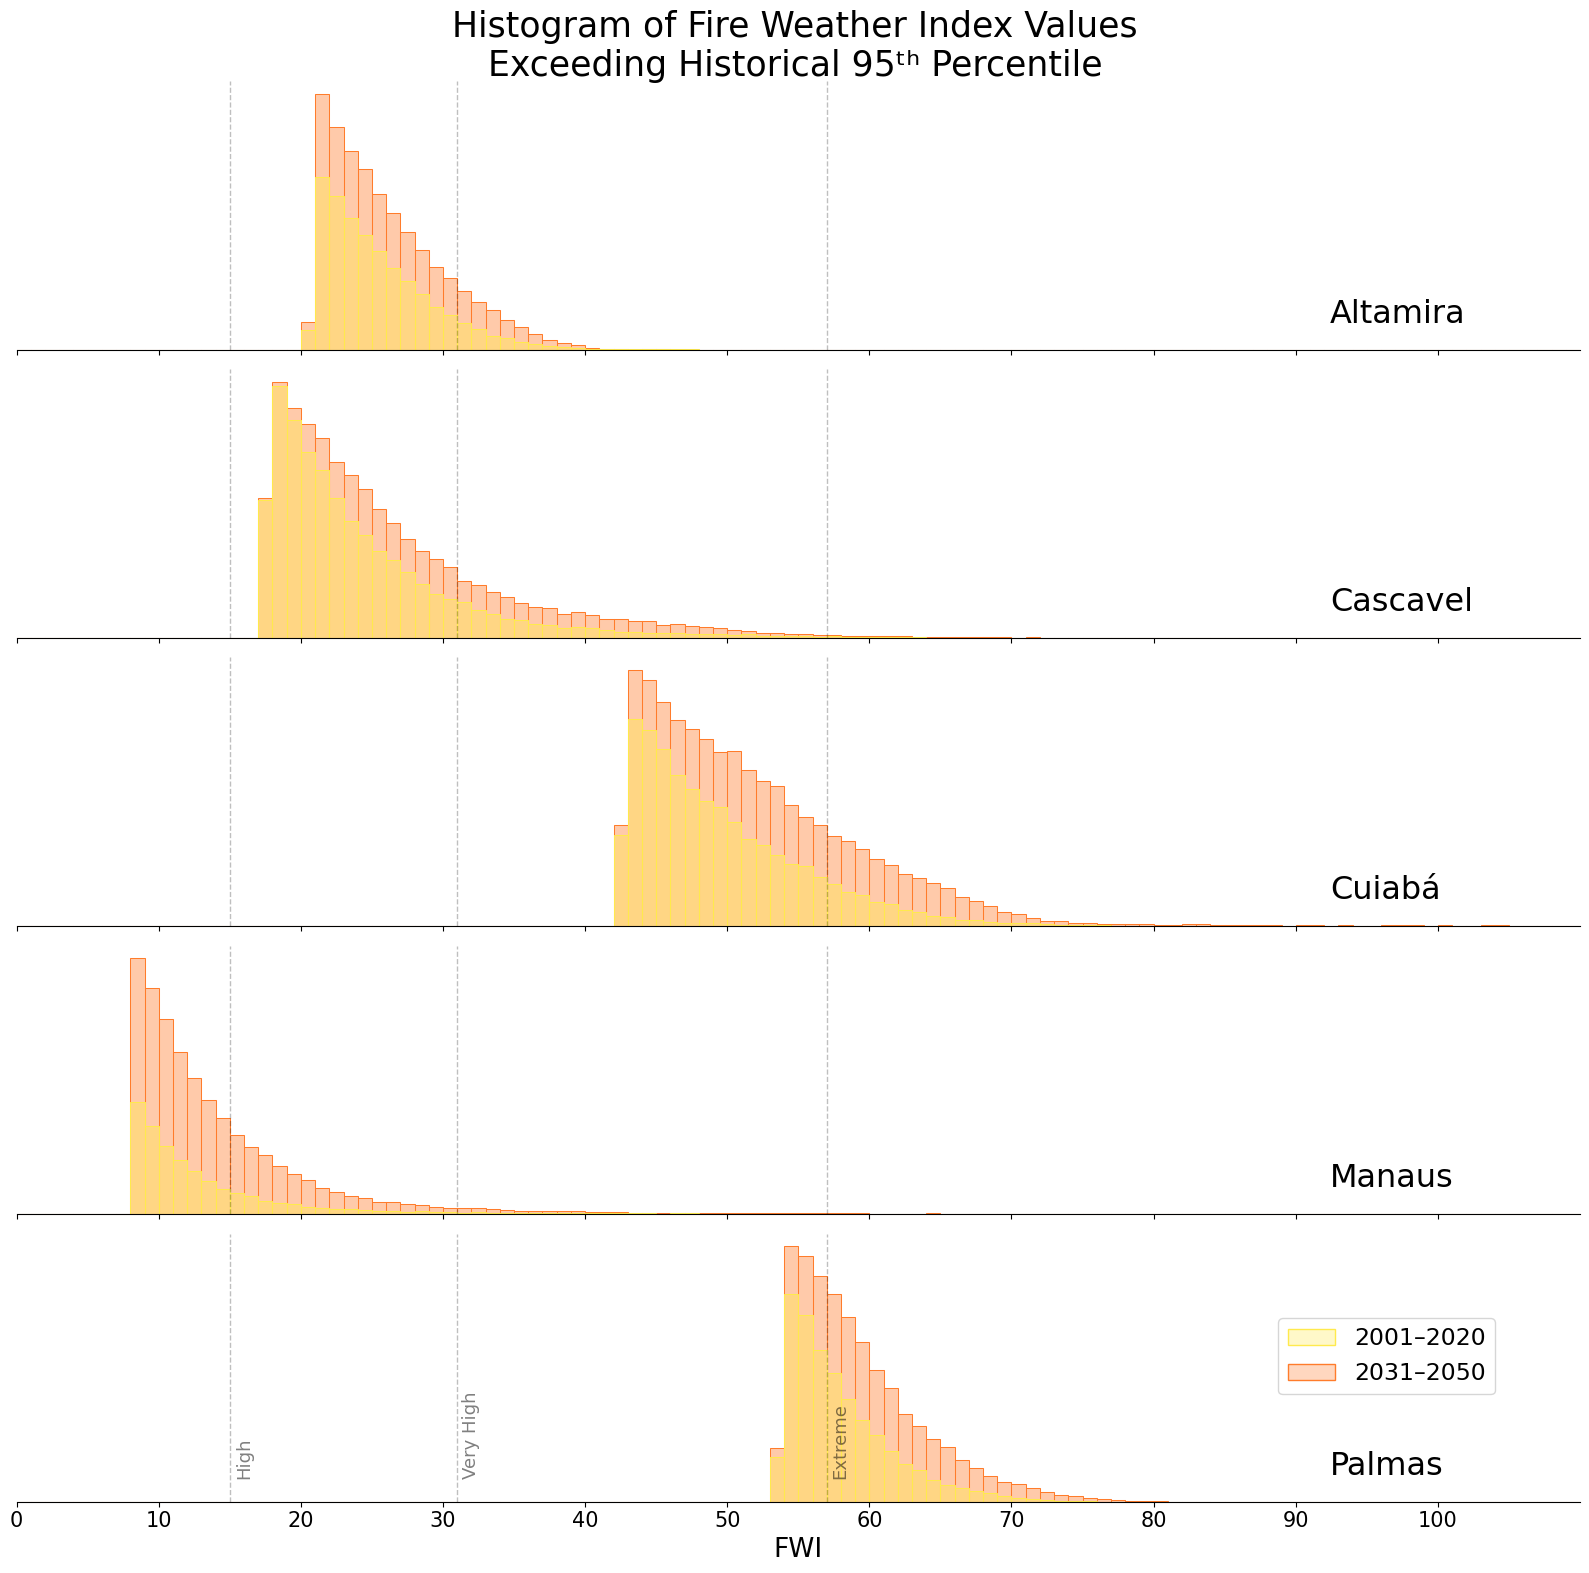

In [24]:
##### plot variable histogram
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from matplotlib import font_manager

font_path = '<font_path>'
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
fontsize = 15
            
if len(yrs_fut2) > 0:
    colors = ['#F5DD27', '#FFAB1C', '#cf6b55']
else:
    colors = ['#FFEA4D', '#FF7C2B']

# bin width
bw = 1

# set xticks, using min/max values of data as guiding limits; round to nearest 'round_to' value
round_to = 10
xtick_min = 0  # np.around(np.min(df_full[var]) / round_to, decimals=0) * round_to
xtick_max = 110  # np.around(np.max(df_full[var]) / round_to, decimals=0) * round_to
ymax_list = []

var_threshold_text_voffset = 13000  # adjust to move variable-threshold label text up (lower #) or down (higher #)

fig, axes = plt.subplots(len(locs_dict), 1, figsize=(16, 16))  # (width, height) of figure

# plot each time period for each location
for i, loc in enumerate(locs_dict.keys()):
    if len(locs_dict.items()) > 1:
        ax = axes[i]
    else:
        ax = axes
        
    for c in reversed(np.arange(len(colors))):  # number of colors corresponds with number of time periods
        if c == 0:
            d = df_full[(df_full['time'] >= f'{yrs_base[0]}-01-01') & (df_full['time'] <= f'{yrs_base[-1]}-12-31') & (df_full['location'] == loc)] 
            palette = 'Blues'
        elif c == 1:
            d = df_full[(df_full['time'] >= f'{yrs_fut[0]}-01-01') & (df_full['time'] <= f'{yrs_fut[-1]}-12-31') & (df_full['location'] == loc)] 
            palette = 'Reds'
        elif c == 2:
            d = df_full[(df_full['time'] >= f'{yrs_fut2[0]}-01-01') & (df_full['time'] <= f'{yrs_fut2[-1]}-12-31') & (df_full['location'] == loc)] 
            palette = 'Greys'
        else:
            print('Error! Number of colors does not correspond to the number of time periods!')
       
        # plot histogram of data
        if plot_method == 'individual':  # plot each model separately
            h = sns.histplot(d, x=d[var], hue=d['model'], ax=ax, fill=True, palette=palette, binwidth=bw, binrange=[xtick_min, xtick_max], alpha=0.3)
        elif plot_method == 'ensemble':  # plot all model data as one
            h = sns.histplot(d[var], color=colors[c], edgecolor=colors[c], ax=ax, binwidth=bw, binrange=[xtick_min, xtick_max], alpha=0.4)
        else:
            print('Error! Plot_method should be "ensemble" or "individual"')
        ymax_list = np.append(ymax_list, ax.get_ylim()[1])

    # location label
    ax.text(0.84, 0.1, loc, transform=ax.transAxes, fontsize=fontsize + 8)
    
    # add variable threshold vertical lines
    for k,v in var_thresholds.items():
        if k == 'Low' or k == 'Low-to-Moderate' or k == 'Moderate':
            pass
        else:
            ax.axvline(x=v, color='k', ls='--', lw=1, alpha=0.25)
            if i == len(locs_dict) - 1:  # annotate last plot
                ax.text(v + 0.35, np.max(ymax_list) - var_threshold_text_voffset, k, alpha=0.5, rotation=90, fontsize=fontsize - 2)
    
    ax.set_xlim((xtick_min, xtick_max))
    ax.set_xticks(np.arange(xtick_min, xtick_max, round_to))
    ax.set_yticks([])
    if i != len(locs_dict.items()) -1:
        ax.set_xticklabels('')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

plt.xticks(np.arange(xtick_min, xtick_max, round_to), fontsize=fontsize)
plt.xlabel('FWI', fontsize=fontsize + 4)
plt.ylabel('')

if len(months2include) == 12:
    fig.suptitle(f'Histogram of Fire Weather Index Values\nExceeding Historical {percentile}ᵗʰ Percentile', fontsize=fontsize + 10)

# build legend
legend_elements = []
for i in np.arange(len(colors)):
    if i == 0:
        legend_label = f'{yrs_base[0]}\u2013{yrs_base[-1]}'
    elif i == 1:
        legend_label = f'{yrs_fut[0]}\u2013{yrs_fut[-1]}'
    elif i == 2:
        legend_label = f'{yrs_fut2[0]}\u2013{yrs_fut2[-1]}'
    legend_elements.append(mpatches.Patch(facecolor=(colors[i], 0.3), edgecolor=colors[i], label=legend_label))

fig.legend(handles=legend_elements, bbox_to_anchor=(0.945, 0.17), fontsize=fontsize + 2)  # (horizontal, vertical) adjustment from ll corner
fig.subplots_adjust(wspace=0, hspace=0)
fig.tight_layout()

if len(list(locs_dict.values())[0]) == 2:
    plt.savefig(f'{home_dir}/{save_path}/{dataset}/{'_'.join([l.replace(" " , "_") for l in list(locs_dict.keys())])}_{variable}_histogram_{season}_{dataset}_singlepixel_{plot_method}.png')
elif  len(list(locs_dict.values())[0]) == 4:
    plt.savefig(f'{home_dir}/{save_path}/{dataset}/{'_'.join([l.replace(" " , "_") for l in list(locs_dict.keys())])}_{variable}_histogram_{season}_{dataset}_latlonbox_{plot_method}.png')
else:
    print('Error! Lat and lons should be a single point (len == 2) or box (len == 4)!')

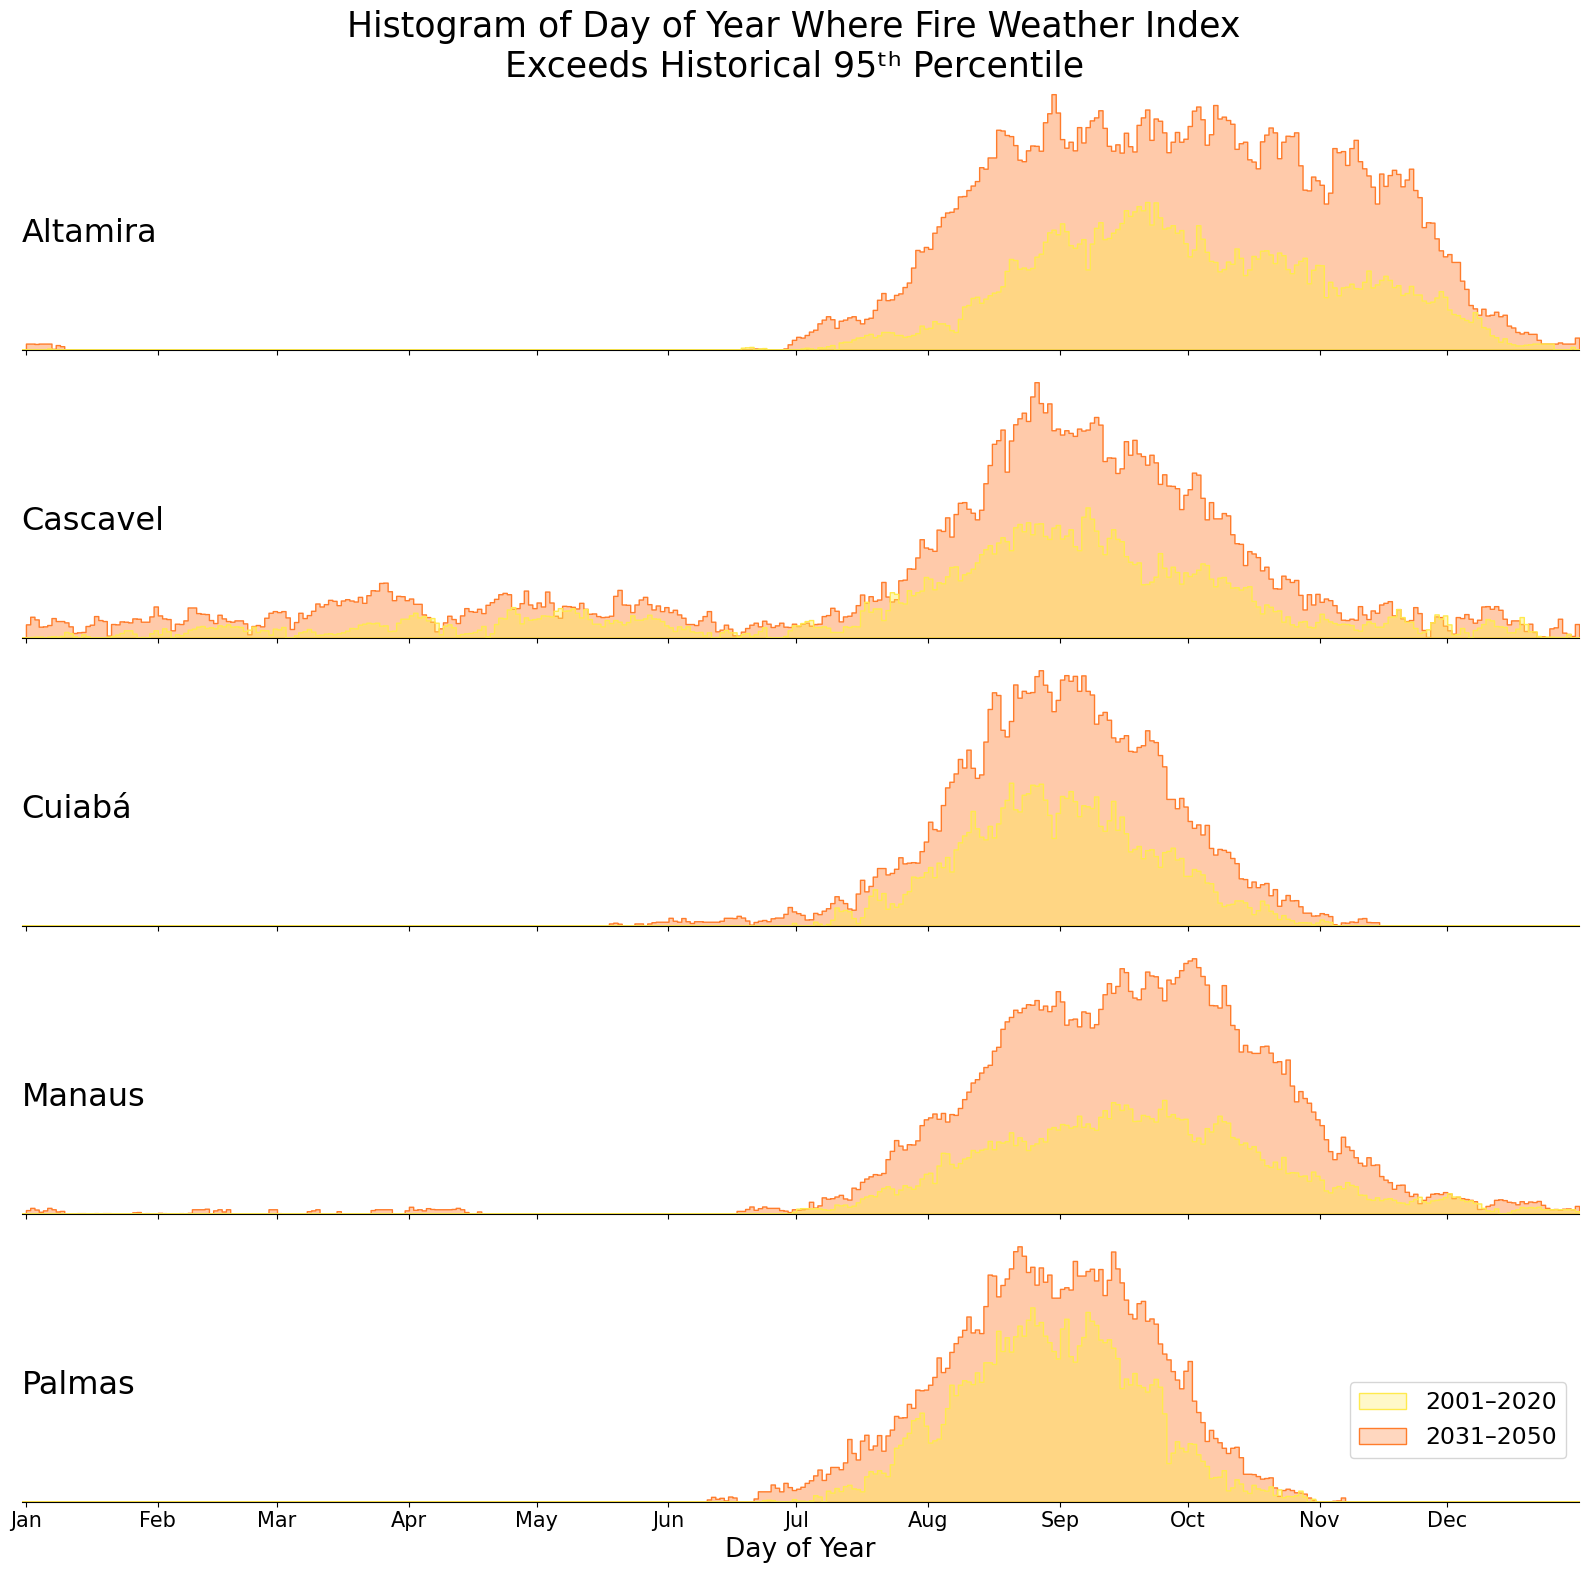

In [32]:
# plot doy histogram
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from matplotlib import font_manager
import pandas as pd

font_path = '<font_path>'
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
fontsize = 15

# bin width
bw = 1

# set xticks (days in year)
xtick_min, xtick_max = 0, 366
ymax_list = []

fig, axes = plt.subplots(len(locs_dict), 1, figsize=(16, 16))  # (width, height) of figure

# plot each time period for each location
for i, loc in enumerate(locs_dict.keys()):
    if len(locs_dict.items()) > 1:
        ax = axes[i]
    else:
        ax = axes
    
    for c in reversed(np.arange(len(colors))):  # number of colors corresponds with number of time periods
        if c == 0:
            d = df_full[(df_full['time'] >= f'{yrs_base[0]}-01-01') & (df_full['time'] <= f'{yrs_base[-1]}-12-31') & (df_full['location'] == loc)] 
        elif c == 1:
            d = df_full[(df_full['time'] >= f'{yrs_fut[0]}-01-01') & (df_full['time'] <= f'{yrs_fut[-1]}-12-31') & (df_full['location'] == loc)] 
        elif c == 2:
            d = df_full[(df_full['time'] >= f'{yrs_fut2[0]}-01-01') & (df_full['time'] <= f'{yrs_fut2[-1]}-12-31') & (df_full['location'] == loc)] 
        else:
            print('Error! Number of colors does not correspond to the number of time periods!')

        # histogram of doy
        doy = d['time'].dt.dayofyear  # convert calendar to remove leap days for easier plotting

        h = sns.histplot(doy, color=colors[c], element='step', ax=ax, binwidth=bw, binrange=[0, 366], alpha=0.4)
        ymax_list = np.append(ymax_list, ax.get_ylim()[1])
        
    # location label
    ax.text(0.0, 0.4, loc, transform=ax.transAxes, fontsize=fontsize + 8)         

    ax.set_xlim((xtick_min, xtick_max))
    ax.set_xticks([1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335])
    ax.set_yticks([])
    if i != len(locs_dict.items()) -1:
        ax.set_xticklabels('')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

plt.xticks([1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335], \
           ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', \
            'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], fontsize=fontsize)
plt.xlabel('Day of Year', fontsize=fontsize + 4)
plt.ylabel('')

if len(months2include) == 12:
    fig.suptitle('Histogram of Day of Year Where Fire Weather Index\nExceeds Historical %dᵗʰ Percentile' \
                 % percentile, fontsize=fontsize + 10)

# build legend
legend_elements = []
for i in np.arange(len(colors)):
    if i == 0:
        legend_label = f'{yrs_base[0]}\u2013{yrs_base[-1]}'
    elif i == 1:
        legend_label = f'{yrs_fut[0]}\u2013{yrs_fut[-1]}'
    elif i == 2:
        legend_label = f'{yrs_fut2[0]}\u2013{yrs_fut2[-1]}'
    legend_elements.append(mpatches.Patch(facecolor=(colors[i], 0.3), edgecolor=colors[i], label=legend_label))
    
fig.legend(handles=legend_elements, bbox_to_anchor=(0.99, 0.13), fontsize=fontsize + 2)  # (horizontal, vertical) adjustment from ll corner
fig.subplots_adjust(wspace=0, hspace=0)
fig.tight_layout()

if len(list(locs_dict.values())[0]) == 2:
    plt.savefig(f'{home_dir}/{save_path}/{dataset}/{'_'.join([l.replace(" " , "_") for l in list(locs_dict.keys())])}_{variable}_histogram_{season}_doy_{dataset}_singlepixel_{plot_method}.png')
elif  len(list(locs_dict.values())[0]) == 4:
    plt.savefig(f'{home_dir}/{save_path}/{dataset}/{'_'.join([l.replace(" " , "_") for l in list(locs_dict.keys())])}_{variable}_histogram_{season}_doy_{dataset}_latlonbox_{plot_method}.png')
else:
    print('Error! Lat and lons should be a single point (len == 2) or box (len == 4)!')